In [2]:
#Data Preparation and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Load the dataset
df=pd.read_csv(r"C:\Users\Akshay Birare\PycharmProjects\Assignments\Assignment Data Sources\Timeseries\Timeseries\exchange_rate.csv", parse_dates=['date'], index_col="date")
df

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


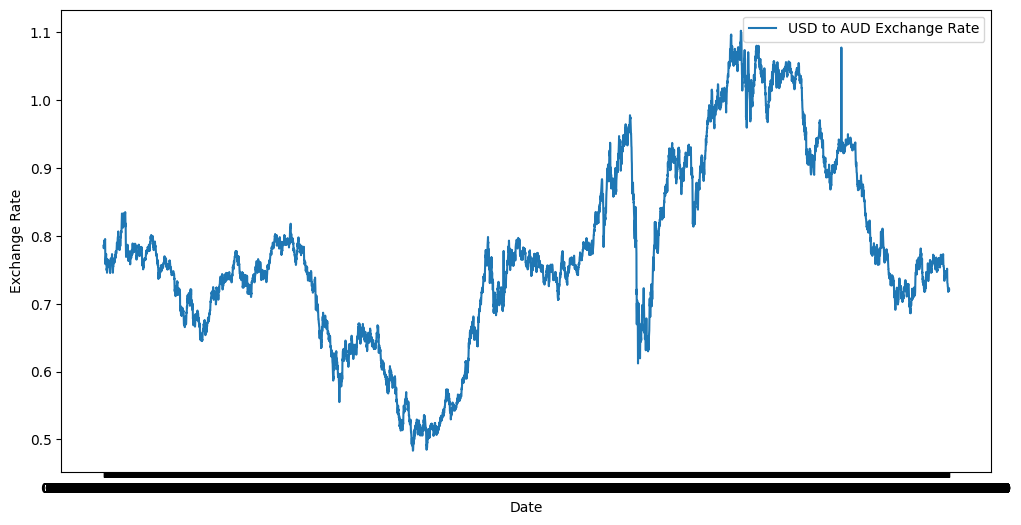

In [5]:
# Plot the time series to understand trends,anomalies & any seasonalities
plt.figure(figsize=(16,9))
plt.plot(df['Ex_rate'],label='USD to AUD Exchange Rate')
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()


In [6]:
#Check for stationarity using the Augmented Dickey-Fuller test
result=adfuller(df)
print("ADF Stats:", result[0])
print("p-value", result[1])
if result[1]>0.05:
    print("The series is non stationary. Differencing is required")
    df=df.diff().dropna()
else:
    print("The series is stationary")

ADF Stats: -1.6649941807381528
p-value 0.4492327353597901
The series is non stationary. Differencing is required


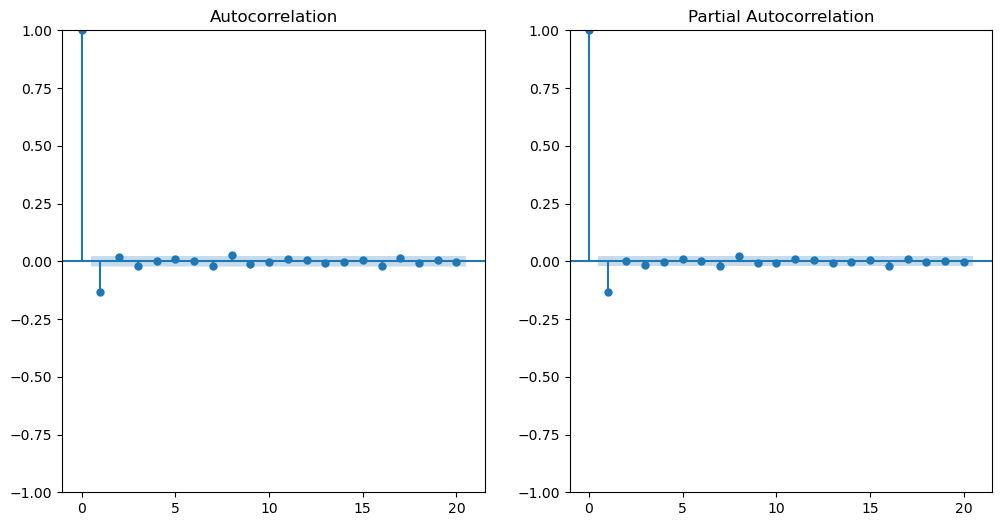

In [27]:
#Model Building - ARIMA
# Plot ACF and PACF for ARIMA parameter selection
plt.figure(figsize=(12, 6))
plt.subplot(121)
sm.graphics.tsa.plot_acf(df['Ex_rate'].dropna(), lags=20, ax=plt.gca())
plt.subplot(122)
sm.graphics.tsa.plot_pacf(df['Ex_rate'].dropna(), lags=20, ax=plt.gca())
plt.show()

In [7]:
# Fit the ARIMA model
arima_model = ARIMA(df['Ex_rate'], order=(1, 1, 1))  # Example order
arima_result = arima_model.fit()
print(arima_result.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7587
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28041.553
Date:                Tue, 15 Apr 2025   AIC                         -56077.106
Time:                        07:51:39   BIC                         -56056.304
Sample:                             0   HQIC                        -56069.967
                               - 7587                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1325      0.002    -60.352      0.000      -0.137      -0.128
ma.L1         -0.9999      0.024    -41.318      0.000      -1.047      -0.952
sigma2      3.585e-05   8.39e-07     42.730      0.0

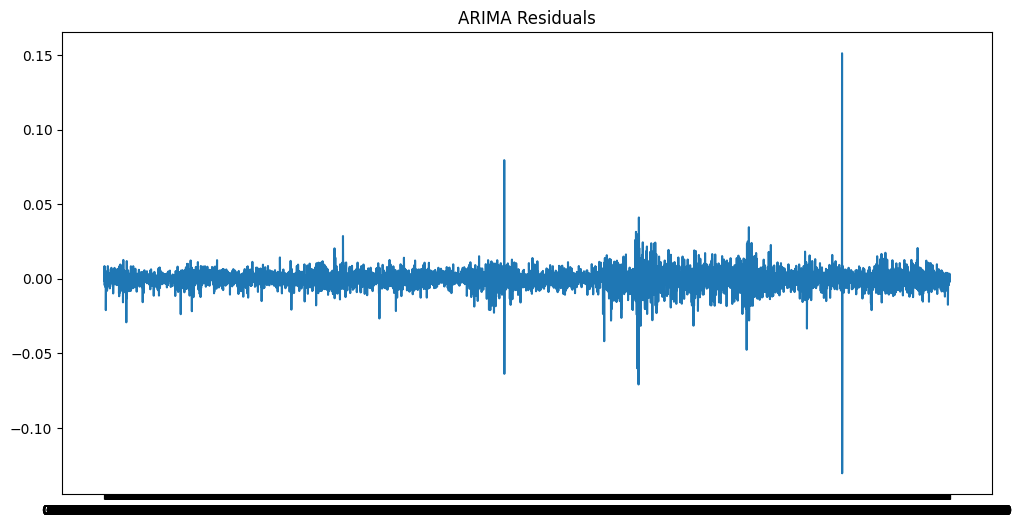

In [8]:
# Diagnostics
arima_residuals = arima_result.resid
plt.figure(figsize=(12, 6))
plt.plot(arima_residuals)
plt.title("ARIMA Residuals")
plt.show()


In [9]:
# Forecasting
forecast = arima_result.forecast(steps=10)
print("Forecast:", forecast)


Forecast: 7587   -0.000152
7588   -0.000132
7589   -0.000134
7590   -0.000134
7591   -0.000134
7592   -0.000134
7593   -0.000134
7594   -0.000134
7595   -0.000134
7596   -0.000134
Name: predicted_mean, dtype: float64


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
# Model Building - Exponential Smoothing
# Fit the Holt-Winters model
hw_model = ExponentialSmoothing(df['Ex_rate'], trend='add', seasonal=None, seasonal_periods=12)
hw_result = hw_model.fit()
print("Holt-Winters Model Params:", hw_result.params)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Holt-Winters Model Params: {'smoothing_level': 0.0028163166464122836, 'smoothing_trend': 0.0007999984214459138, 'smoothing_seasonal': nan, 'damping_trend': nan, 'initial_level': 7.692496312611144e-05, 'initial_trend': 2.2137002241948108e-08, 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


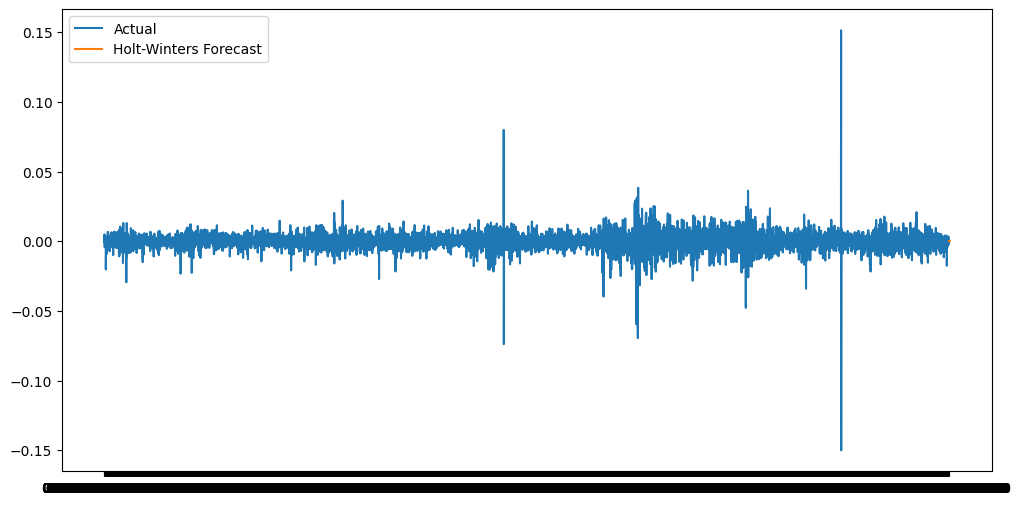

In [11]:
# Forecasting
hw_forecast = hw_result.forecast(steps=10)
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], label="Actual")
plt.plot(hw_forecast, label="Holt-Winters Forecast")
plt.legend()
plt.show()


In [12]:
# Part 4: Evaluation and Comparison
# Calculate error metrics
arima_mae = mean_absolute_error(df['Ex_rate'][-10:], forecast)  # Replace with appropriate validation data
arima_rmse = np.sqrt(mean_squared_error(df['Ex_rate'][-10:], forecast))

hw_mae = mean_absolute_error(df['Ex_rate'][-10:], hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(df['Ex_rate'][-10:], hw_forecast))

print(f"ARIMA - MAE: {arima_mae}, RMSE: {arima_rmse}")
print(f"Holt-Winters - MAE: {hw_mae}, RMSE: {hw_rmse}")


ARIMA - MAE: 0.0014615987732287132, RMSE: 0.0019422032842672395
Holt-Winters - MAE: 0.0014714650270209928, RMSE: 0.0019475273804328958


In [13]:
# Compare models
if arima_rmse < hw_rmse:
    print("ARIMA performs better.")
else:
    print("Holt-Winters performs better.")

ARIMA performs better.
